In [519]:
import math
import numpy as np
import pandas as pd

import pandapower as pp
import pandapower.networks as pn
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# helper functions for plotting graphs and waveforms

# prints graph
def print_graph(G: nx.Graph):
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1000, font_size=16)
    plt.show()


# plots the graph waveform
def plot_node_waveforms(S, nodes):
    t = np.arange(S.shape[0])
    n = len(nodes)

    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = np.array(axes).reshape(-1)

    for i, node in enumerate(nodes):
        axes[i].plot(t, S[:, i])
        axes[i].set_title(f'Node {node}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Flow')
        axes[i].grid(True)

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


# plots the edge waveform
def plot_edge_waveforms(F, edges):
    t = np.arange(F.shape[0])
    n = len(edges)

    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = np.array(axes).reshape(-1)

    for i, (u, v) in enumerate(edges):
        axes[i].plot(t, F[:, i])
        axes[i].set_title(f'Edge ({u},{v})')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Flow')
        axes[i].grid(True)

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()



First we build small weighted graph for calculating physics based centrality formulas. We compute effective resistance, current flow betweenness, and a simple DC power flow to see how they relate to each other. The goal is just to test and better understand these formulas on a small example.

Graph structure:



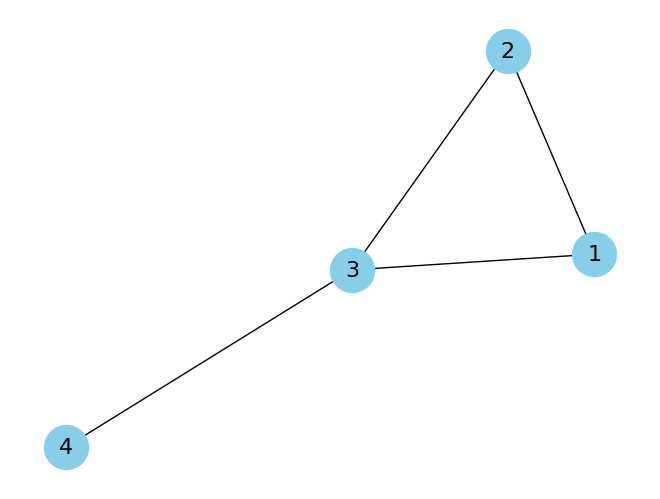


Effective Resistance:
(1, 2): 0.7778
(1, 3): 0.5556
(2, 3): 0.6667
(3, 4): 1.0000

Current Flow Betweenness:
(1, 2): 0.3889
(1, 3): 0.3333
(2, 3): 0.4074
(3, 4): 0.5000

DC Power Flow:
(1, 2): 0.4444
(1, 3): 0.5556
(2, 3): 0.4444
(3, 4): 1.0000


In [520]:

# create random graph with edge features
G = nx.Graph()
edges = [
    (1,2, {'x': 0.1, 'capacity': 5}),
    (1,3, {'x': 0.2, 'capacity': 5}),
    (2,3, {'x': 0.15, 'capacity': 5}),
    (3,4, {'x': 0.3, 'capacity': 5})
]
G.add_edges_from(edges)

# define some node features
nodes = list(G.nodes())
n = len(nodes)
node_index = {node: i for i, node in enumerate(nodes)}

# calculate edge weight B = 1 / X
for u,v,data in G.edges(data=True):
    data['weight'] = 1 / data['x']

# print our graph
print('Graph structure:\n')
print_graph(G)

# calculate Laplacian and its pseudo inverse
L = nx.laplacian_matrix(G, nodelist=nodes, weight='weight').toarray()
L_plus = np.linalg.pinv(L)


# function that computes effective resistance centrality
def compute_effective_resistance(G, L_plus, node_index):
    n = len(node_index)
    eff_cent = {}
    
    # helper that computes R_eff for given edge
    def R_eff(i, j):
        ei = np.zeros(n)
        ej = np.zeros(n)
        ei[node_index[i]] = 1
        ej[node_index[j]] = 1
        diff = ei - ej

        # R_eff = (e_i - e_j)^T * L^+ * (e_i - e_j)
        return diff @ L_plus @ diff

    # iterate over each edge and compute its effective resistace
    for (u,v) in G.edges():
        w = G[u][v]['weight']
        # compute C_e = w_e * R_eff
        eff_cent[(u,v)] = w * R_eff(u, v)
    
    return eff_cent


# function that computes current flow betweenness centrality
def compute_current_flow_betweenness(G, L_plus, node_index):
    nodes = list(G.nodes())
    n = len(nodes)
    curr_flow = {e:0.0 for e in G.edges()}

    # iterate over all unordered node pairs (s, t)
    for s in nodes:
        for t in nodes:
            if s >= t:
                continue
            b = np.zeros(n)
            b[node_index[s]] = 1
            b[node_index[t]] = -1

            # solve for node voltages: x = L^+ b
            x = L_plus @ b

            # compute induced current on each edge
            for (u,v) in G.edges():
                i, j = node_index[u], node_index[v]
                w = G[u][v]['weight']
                flow = w * (x[i] - x[j])
                curr_flow[(u,v)] += abs(flow)

    # normalize by number of node pairs
    num_pairs = n*(n-1)/2
    for e in curr_flow:
        curr_flow[e] /= num_pairs

    return curr_flow


# function that computes simulated DC power flow for flow centrality (estimation)
def compute_dc_power_flow(G, L_plus, node_index):
    nodes = list(G.nodes())
    P = np.zeros(len(nodes))
    P[node_index[1]] = 1.0
    P[node_index[4]] = -1.0

    theta = L_plus @ P

    dc_flow = {}
    for (u,v) in G.edges():
        i, j = node_index[u], node_index[v]
        w = G[u][v]['weight']
        dc_flow[(u,v)] = w * (theta[i] - theta[j])

    return dc_flow


# run calculations for given metrics
eff_cent = compute_effective_resistance(G, L_plus, node_index)
curr_flow = compute_current_flow_betweenness(G, L_plus, node_index)
dc_flow = compute_dc_power_flow(G, L_plus, node_index)

print('\nEffective Resistance:')
for e, val in eff_cent.items():
    print(f'{e}: {val:.4f}')

print('\nCurrent Flow Betweenness:')
for e, val in curr_flow.items():
    print(f'{e}: {val:.4f}')

print('\nDC Power Flow:')
for e, val in dc_flow.items():
    print(f'{e}: {val:.4f}')


Here we Implement the network auralization algorithm for nodes, similar to original one but uses numpy for ease of use. Testing it on several graphs that have a node bottleneck, plotting the waveform for each node to see its effective influence on the network.

[[ 9.11412766e-07  9.11412766e-07  9.11412766e-07 ...  9.11412766e-07
   9.11412766e-07  4.99990465e-01]
 [-4.99990886e-02 -4.99990886e-02 -4.99990886e-02 ... -4.99990886e-02
  -4.99990886e-02 -1.00009535e-01]
 [-3.64990886e-02 -3.64990886e-02 -3.64990886e-02 ... -3.64990886e-02
  -3.64990886e-02 -4.88009535e-01]
 ...
 [ 4.69791570e-06  4.69791570e-06  4.69791570e-06 ...  4.69791574e-06
   4.69791574e-06 -4.35236891e-06]
 [-1.77830651e-06 -1.77830651e-06 -1.77830651e-06 ... -1.77830649e-06
  -1.77830649e-06 -1.60739008e-05]
 [-4.64689092e-06 -4.64689092e-06 -4.64689092e-06 ... -4.64689091e-06
  -4.64689091e-06 -1.54105539e-05]]


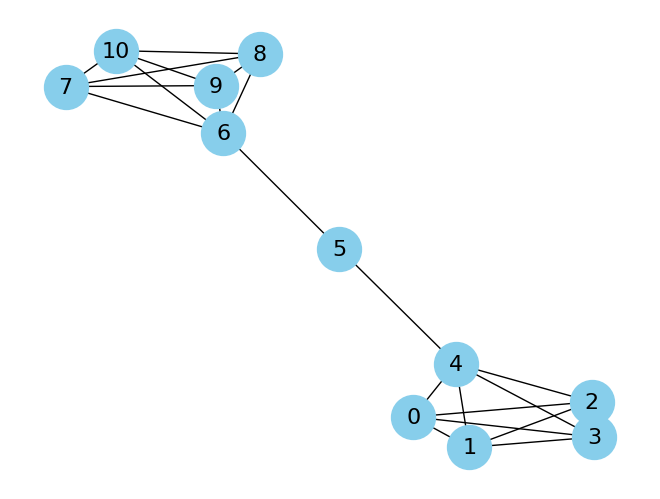

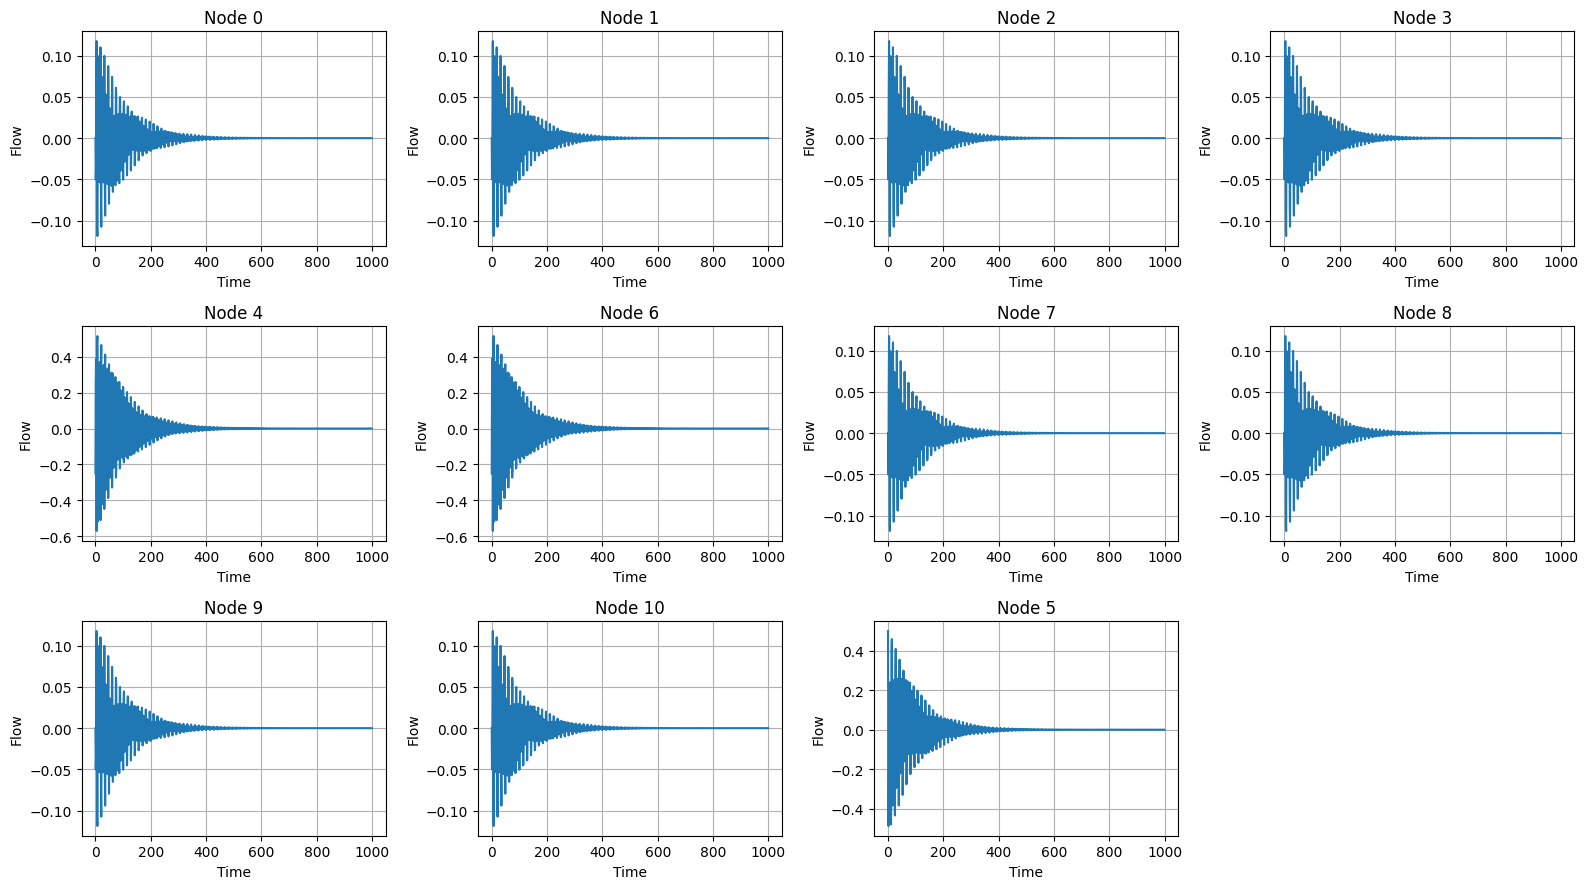

In [521]:

def network_auralization(G, nodes, sig=None, m=0.9, l=100):
    n = len(nodes)

    # adjacency matrix for given graph G
    A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')

    # initialize transition matrix and with normalize columns for getting
    # transition probabilites for each node (power it may apply to its neighbors)
    col_sum = A.sum(axis=0) + 1e-32 # add small value to avoid division by zero
    P = (A / col_sum).T

    # initialize S matrix with initial condition
    S = np.zeros((l, n))

    # initialize delta S matrix to zeros for initail flow between nodes 
    DELTA_S = np.zeros((n, n))

    # if no signal provided, use default condition (1 for all nodes at time 0)
    if sig is None:
        sig = np.zeros(l)
        sig[0] = 1

    # simulation of wave propagation over l time steps
    for t in range(1, l):
        # add signal injection to St-1 before propagation
        S[t-1] += sig[(t-1) % len(sig)]

        # create diagonal matrix from St-1
        diag_S = np.diag(S[t-1])

        # update delta_S based on how much power each node applies to its neighbors
        DELTA_S = diag_S @ P + m * DELTA_S # include previous flow momentum

        # calculate inflow and outflow for each node
        inflow = DELTA_S.sum(axis=0)
        outflow = DELTA_S.sum(axis=1)

        # update S based on inflow and outflow
        S[t] = S[t-1] + inflow - outflow

    # remove DC component
    S = S - S.mean(axis=0)

    return S



# test the network auralization function on small graphs
G_star = nx.star_graph(5)

G_path = nx.path_graph(6)

G_bottleneck = nx.Graph()
G_bottleneck.add_edges_from([
    (1,2),(2,3),(3,4),
    (4,5),(5,6),
    (3,7),(7,8)
])

G_bottleneck2 = nx.Graph()
G_bottleneck2.add_edges_from([
    (1,2), (1,3), (2,3), (3,4)
])

G_barbell = nx.barbell_graph(5, 1)

G_grid = nx.grid_2d_graph(5,5)
G_grid = nx.convert_node_labels_to_integers(G_grid)

# test graph
G = G_barbell
nodes = list(G.nodes())

S = network_auralization(G, nodes, m=0.98, l=1000)
print(S)
print_graph(G)
plot_node_waveforms(S, nodes)



Here, I implemented the network auralization algorithm for edges, similar to the original approach, but using a new F matrix that stores a time series for each edge. Each edge’s series is computed as F[(u,v)] = S[u] + S[v].<br> Tested it on pervious graphs from earlier and plotted waveform for edges for visualization.

[[ 5.01636768e-06 -4.99993769e-01 -4.99993769e-01 -5.01636761e-06]
 [-3.33328317e-01  3.33339564e-01  3.33339564e-01  3.33328317e-01]
 [-1.59994984e-01  5.66672898e-01  5.66672898e-01  1.59994984e-01]
 ...
 [ 2.51041267e-06 -7.45181335e-06 -7.45181335e-06 -2.51041262e-06]
 [-9.00663982e-06  2.73796024e-05  2.73796024e-05  9.00663985e-06]
 [ 5.49165001e-06  2.50979017e-05  2.50979017e-05 -5.49164999e-06]]


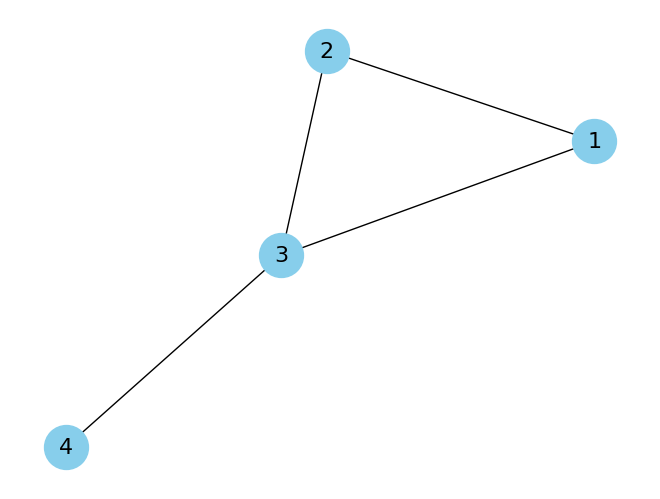

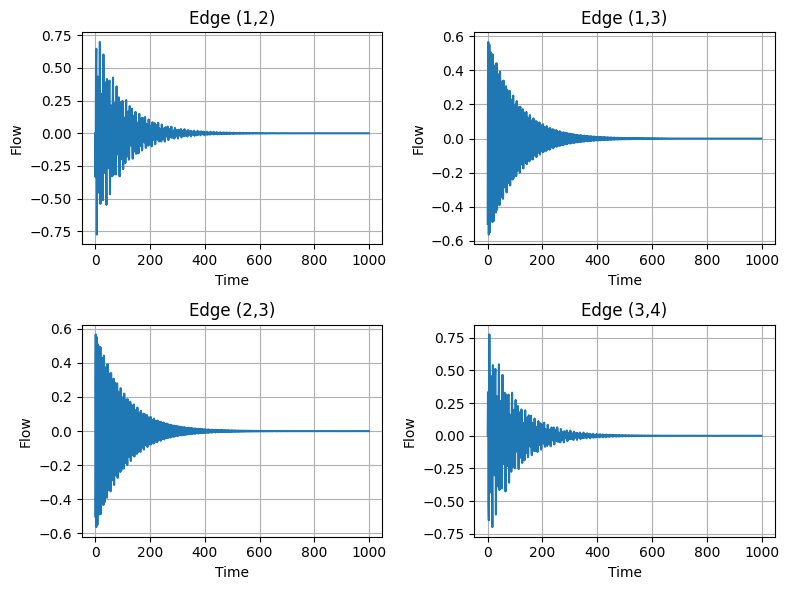

In [522]:

def network_auralization_edges(G, nodes, edges, sig=None, m=0.9, l=100):
    n = len(nodes)
    m_edges = len(edges)
    node_index = {node: i for i, node in enumerate(nodes)}

    # adjacency matrix for given graph G
    A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')

    # initialize transition matrix and with normalize columns for getting
    # transition probabilites for each node (power it may apply to its neighbors)
    col_sum = A.sum(axis=0) + 1e-32 # add small value to avoid division by zero
    P = (A / col_sum).T

    # initialize S matrix with initial condition
    S = np.zeros((l, n))

    # initialize delta_S matrix to zeros for initail flow between nodes 
    DELTA_S = np.zeros((n, n))

    #? this is for edge-based flow, we need to track flow on edges, we create row and colum indices for edges
    #? each edge (u, v) gets its own index / number, so we can track flows for it
    row_idx = np.array([node_index[u] for u, v in edges])
    col_idx = np.array([node_index[v] for u, v in edges])

    #? Ft matrix represents flow on edges over time (like St)
    F = np.zeros((l, m_edges))

    # if no signal provided, use default condition (1 for all nodes at time 0)
    if sig is None:
        sig = np.zeros(l)
        sig[0] = 1

    # simulation of wave propagation over l time steps
    for t in range(1, l):
        # add signal injection to St-1 before propagation
        S[t-1] += sig[(t-1) % len(sig)]

        # create diagonal matrix from St-1
        diag_S = np.diag(S[t-1])

        # update delta_S based on how much power each node applies to its neighbors
        DELTA_S = diag_S @ P + m * DELTA_S # include previous flow momentum

        # calculate inflow and outflow for each node
        inflow = DELTA_S.sum(axis=0)
        outflow = DELTA_S.sum(axis=1)

        # update S based on inflow and outflow
        S[t] = S[t-1] + inflow - outflow

    #? calculate flow on edges from S, represent flow on edge (u, v) as S[u] + S[v] (flow on both nodes)
    F = S[:, row_idx] + S[:, col_idx]

    #? remove DC component for edge flows
    F = F - F.mean(axis=0)

    return F



# test the network auralization function on small graphs
G_star = nx.star_graph(5)

G_path = nx.path_graph(6)

G_bottleneck = nx.Graph()
G_bottleneck.add_edges_from([
    (1,2),(2,3),(3,4),
    (4,5),(5,6),
    (3,7),(7,8)
])

G_bottleneck2 = nx.Graph()
G_bottleneck2.add_edges_from([
    (1,2), (1,3), (2,3), (3,4)
])

G_barbell = nx.barbell_graph(5, 1)

G_grid = nx.grid_2d_graph(5,5)
G_grid = nx.convert_node_labels_to_integers(G_grid)

# test graph
G = G_bottleneck2
nodes, edges = list(G.nodes()), list(G.edges())

F = network_auralization_edges(G, nodes, edges, m=0.98, l=1000)
print(F)
print_graph(G)
plot_edge_waveforms(F, edges)



In this section we start working on power grid networks, using PandaPower to compute power flow on various IEEE networks. In this section we have simple helper functions for converting PandaPower network to networkX graphs and plotting it for visualization. Note that we compute the suseptance for each edge and have it as a weight for later calculations.

In [523]:
# function for building network graph including various power network features for buses and branches
def build_network_graph(network: pp.pandapowerNet, is_weighted=True):
    G = nx.MultiGraph()
    NUM_LINES = len(network.line)

    # represents nodes and edges lists, we maintain them for later easy access to features
    nodes, edges = [], []

    # add nodes to our network graph
    for bus in network.bus.index:
        vn_kv = network.bus.at[bus, 'vn_kv'] # nominal voltage
        p_load = network.load[network.load.bus == bus].p_mw.sum() if not network.load.empty else 0.0 # active load
        q_load = network.load[network.load.bus == bus].q_mvar.sum() if not network.load.empty else 0.0 # reactive load
        p_sgen = network.sgen[network.sgen.bus == bus].p_mw.sum() if not network.sgen.empty else 0.0 # active static generation
        q_sgen = network.sgen[network.sgen.bus == bus].q_mvar.sum() if not network.sgen.empty else 0.0 # reactive static generation
        p_gen = network.gen[network.gen.bus == bus].p_mw.sum() if not network.gen.empty else 0.0 # active conventional generation

        G.add_node(bus, vn_kv=vn_kv, p_load=p_load, q_load=q_load, p_sgen=p_sgen, q_sgen=q_sgen, p_gen=p_gen)
        nodes.append(bus)

    # add edges for lines to our network graph
    for idx, (pp_idx, line) in enumerate(network.line.iterrows()):
        r = line.r_ohm_per_km * line.length_km # resistance of line
        x = line.x_ohm_per_km * line.length_km # reactance of line
        z = np.sqrt(r**2 + x**2) # impedance magnitude |Z| = sqrt(R^2 + X^2)
        y_mag = 1 / max(z, 1e-6) # admittance magnitude |Y| = 1 / |Z|
        rx_ratio = r / max(x, 1e-6) # ratio between resistance & reactance

        G.add_edge(line.from_bus, line.to_bus, key=f'line_{idx}', index=idx, pp_index=pp_idx, type='line', r=r, x=x, z=z, y_mag=y_mag, rx_ratio=rx_ratio, weight=y_mag if is_weighted else 1.0)
        edges.append((line.from_bus, line.to_bus, f'line_{idx}'))

    # add edges for transformers to our network graph
    for idx, (pp_idx, trafo) in enumerate(network.trafo.iterrows()):
        r = trafo.vkr_percent / 100 * (trafo.vn_hv_kv ** 2) / trafo.sn_mva # resistance of line
        x = np.sqrt(max((trafo.vk_percent / 100)**2 - (trafo.vkr_percent / 100)**2, 0)) * (trafo.vn_hv_kv ** 2) / trafo.sn_mva # reactance of line
        z = np.sqrt(r**2 + x**2) # impedance magnitude
        y_mag = 1 / max(z, 1e-6) # admittance magnitude
        rx_ratio = r / (x + 1e-6) # ratio between resistance & reactance

        G.add_edge(trafo.hv_bus, trafo.lv_bus, key=f'trafo_{idx}', index=NUM_LINES + idx, pp_index=pp_idx, type='trafo', r=r, x=x, z=z, y_mag=y_mag, rx_ratio=rx_ratio, weight=y_mag if is_weighted else 1.0)
        edges.append((trafo.hv_bus, trafo.lv_bus, f'trafo_{idx}'))

    # we return new graph with nodes and edges lists
    return G, nodes, edges


# function for printing network graph for visualization
def print_network_graph(G: nx.MultiGraph, title=''):
    # define our figure size based on num of nodes
    num_nodes = len(G.nodes)
    fig_width = max(10, num_nodes // 5)
    fig_height = max(8, num_nodes // 5)
    plt.figure(figsize=(fig_width, fig_height))

    # if small graph print shell layout, else spring for larger graphs
    if num_nodes <= 20:
        pos = nx.shell_layout(G)
    else:
        pos = nx.spring_layout(G, seed=42, k=0.5 / (num_nodes**0.5), iterations=200)

    # draw our nodes and labels
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=9)

    # get edges type to draw them seperately (lines vs transformers)
    line_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('type') == 'line']
    trafo_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('type') != 'line']

    # draw our edges, transformers are dashed
    nx.draw_networkx_edges(G, pos, edgelist=line_edges, edge_color='black', width=2)
    nx.draw_networkx_edges(G, pos, edgelist=trafo_edges, edge_color='grey', style='dashed', width=2)

    # draw edge label indices for referace later on
    edge_labels = {(u, v): d.get('index', '') for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # draw small legend for buses, lines and transformers
    bus_legend = mlines.Line2D([], [], color='lightblue', marker='o', linestyle='None', markersize=8, label='Bus')
    line_legend = mlines.Line2D([], [], color='black', linewidth=2, label='Line')
    trafo_legend = mlines.Line2D([], [], color='grey', linestyle='dashed', linewidth=2, label='Transformer')
    plt.legend(handles=[bus_legend, line_legend, trafo_legend], loc='upper right')

    plt.title(f'{title} Network Graph: Buses, Lines & Transformers (dashed)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In this section, I implemented the main function to simulate network power flow. First, we compute the baseline flow with all links and transformers connected. Then, we simulate an outage on each branch and measure how the flows change on the rest of the network. Both AC and DC flows can be measured, and the results are stored in a delta_P matrix, where each row shows the power changes on all branches when a specific link is disconnected.

In [524]:

# fucntion for computing edge betweeness centrality for our network graph
def compute_edge_betweeness(G: nx.Graph, is_weighted=True):
    edge_betweenness = nx.edge_betweenness_centrality(G, weight='weight' if is_weighted else None)
    betweenness_values = np.zeros(len(G.edges()))

    # iterate over edges and assign betweenness values based on our edge index from graph
    for u, v, k, d in G.edges(keys=True, data=True):
        idx = d['index']
        betweenness_values[idx] = edge_betweenness[(u, v, k)]
    
    return betweenness_values


# simulate power flow on network, AC or DC
def run_power_flow(network: pp.pandapowerNet, use_dc=False):
    pp.runpp(network) if not use_dc else pp.rundcpp(network)


# main function for simulating network outage on edges and compute delta_P matrix
def network_outage_impact(network: pp.pandapowerNet, G: nx.MultiGraph, edges, use_dc=False, use_abs=True):
    # define number of branches in given network
    NUM_BRANCHES = len(edges)

    # define our delta_P matrix that represents each line impact
    # on the other lines (power outage)
    DELTA_P = np.zeros((NUM_BRANCHES, NUM_BRANCHES))

    # compute network power baseline with all lines connected
    run_power_flow(network, use_dc)
    baseline_lines = network.res_line['p_from_mw'].values
    baseline_trafos = network.res_trafo['p_hv_mw'].values
    baseline = np.concatenate([baseline_lines, baseline_trafos])

    # iterate over each line/tarnfo and simulate its outage, compute new power flow on network
    for (u, v, k) in edges:
        # get edge indices and type for simulating outage
        edge_idx = G[u][v][k]['index']
        pp_idx = G[u][v][k]['pp_index']
        edge_type = G[u][v][k]['type']

        # remove current line/tranfo from our network
        if edge_type == 'line':
            network.line.at[pp_idx, 'in_service'] = False
        else:
            network.trafo.at[pp_idx, 'in_service'] = False

        try:
            # run full power flow on our network without currrnt line/tranfo and compute new flow
            run_power_flow(network, use_dc)
            flow_lines = network.res_line['p_from_mw'].values
            flow_trafos = network.res_trafo['p_hv_mw'].values
            total_flow = np.concatenate([flow_lines, flow_trafos])

            # compute the delta between new flow and baseline, use absolute if given
            DELTA_P[edge_idx] = total_flow - baseline if not use_abs else np.abs(total_flow - baseline)

        #! if exception occured it means power flow didnt converge, means network is unstable or got disconnected, importent case to handle
        except pp.LoadflowNotConverged:
            # assign large value to delta to indicate significant impact for this line/tranfo
            max_delta = np.nanmax(DELTA_P)
            DELTA_P[edge_idx] = max_delta + 0.1 * max_delta

        # add current line/tranfo back to out network for later iterations
        if edge_type == 'line':
            network.line.at[pp_idx, 'in_service'] = True
        else:
            network.trafo.at[pp_idx, 'in_service'] = True
    
    return DELTA_P, baseline


# helper fucntion for computing flow centrality on given network using our simulation
def compute_flow_centrality(network: pp.pandapowerNet, G: nx.MultiGraph, edges, use_dc=False, normalize=False):
    DELTA_P, _ = network_outage_impact(network, G, edges, use_dc=use_dc)
    impact = np.linalg.norm(DELTA_P, axis=1)

    # return normalized impact values using min-max normalization
    if normalize:
        impact = (impact - impact.min()) / (impact.max() - impact.min() + 1e-12)

    return impact



Test the edge auralization algorithm on IEEE-14 for visualization of the waveforms.

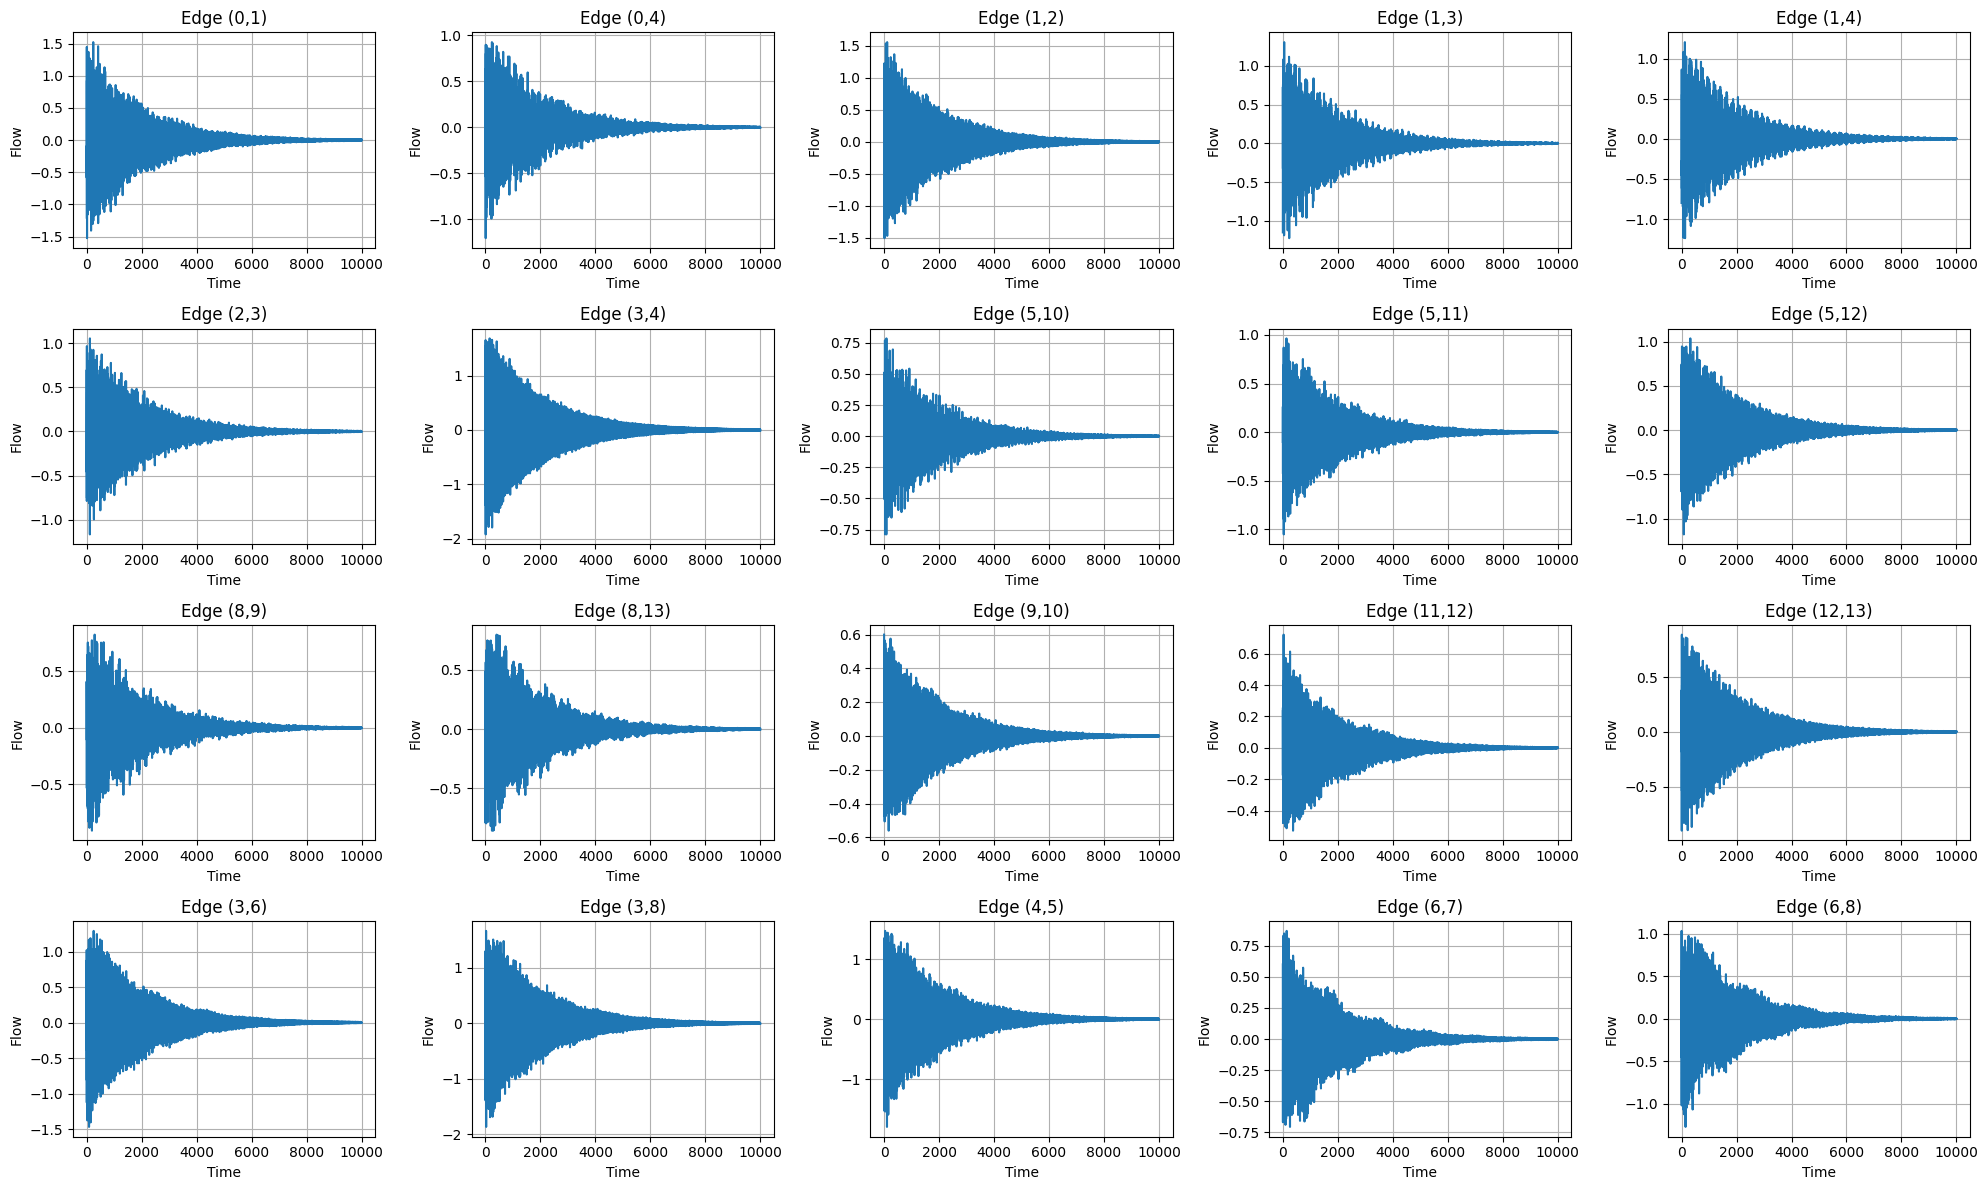

In [525]:
network = pn.case14()
G, nodes, edges = build_network_graph(network, is_weighted=False)
edges = [(u, v) for u, v, _ in edges] # create list without k for auralization
F = network_auralization_edges(G, nodes, edges, m=0.999, l=10000)
plot_edge_waveforms(F, edges)

In [526]:
# function for creating dataframe dataset for our ML models with various power networks 
def create_power_network_dataset(network_list: list[tuple], m=0.98, l=1000, is_weighted=False, normalize=False):
    X_wavefroms, y_targets, dc_targets, metadata = [], [], [], [] 

    for name, network in network_list:
        print(f'Processing network: {name}.')

        # create network graph for computing AC flow and wavefroms
        G, nodes, edges = build_network_graph(network, is_weighted=is_weighted)

        # compute AC power flow on each edge in network
        edge_impact_ac = compute_flow_centrality(network, G, edges, use_dc=False, normalize=normalize)

        # compute DC power flow for comparing later with our predictions
        edge_impact_dc = compute_flow_centrality(network, G, edges, use_dc=True, normalize=normalize)

        # compute auralization waveform for each edge in network
        edges = [(u, v) for u, v, _ in edges] # create list without k for auralization
        F = network_auralization_edges(G, nodes, edges, m=m, l=l)
        F_edges = F.T # transpose the matrix to be of shape m x l

        # append to dataset
        X_wavefroms.append(F_edges)
        y_targets.append(edge_impact_ac)
        dc_targets.append(edge_impact_dc)
        metadata.extend([(name, i) for i in range(F_edges.shape[0])])

    # combine our waveforms matrices and targets
    X = np.vstack(X_wavefroms)
    dc = np.concatenate(dc_targets)
    y = np.concatenate(y_targets)

    # create column names t0, t1, ..., t_n-1
    time_steps = X.shape[1]
    column_names = [f't{i}' for i in range(time_steps)]

    # create dataset dataframe
    df = pd.DataFrame(X, columns=column_names)
    df.insert(0, 'network', [n for n, i in metadata])
    df.insert(1, 'edge_index', [i for n, i in metadata])
    df['dc_approx'] = dc
    df['target'] = y

    return df

# we will create our dataset using seven power gird networks including those we tested earlier
networks = [(14, pn.case14()), (57, pn.case57()), (118, pn.case118()), (300, pn.case300()), (30, pn.case30()), (39, pn.case39()), (145, pn.case145())]
aura_dataset = create_power_network_dataset(networks, m=0.98, l=1000, is_weighted=False, normalize=True)

aura_dataset


Processing network: 14.
Processing network: 57.
Processing network: 118.
Processing network: 300.
Processing network: 30.
Processing network: 39.
Processing network: 145.


,network,edge_index,t0,t1,t2,t3,t4,t5,t6,t7,...,t992,t993,t994,t995,t996,t997,t998,t999,dc_approx,target
0,14,0,-0.099972,-0.149972,-0.394805,-0.574742,-0.133095,0.851637,1.365548,0.628246,...,0.000069,0.000033,0.000002,1.728138e-05,0.000061,0.000079,0.000044,-0.000008,1.000000,1.000000
1,14,1,-0.099974,-0.399974,-0.406474,0.080406,0.488632,0.328482,-0.027251,0.101843,...,0.000005,0.000031,0.000060,5.933370e-05,0.000033,0.000014,0.000019,0.000030,0.481345,0.465156
2,14,2,-0.099972,-0.199972,-0.427139,-0.472512,0.074284,0.936614,1.144344,0.242451,...,0.000079,0.000054,0.000007,-4.565714e-07,0.000044,0.000081,0.000057,-0.000007,0.475248,0.440423
3,14,3,-1.149953,-0.116620,0.708547,0.482738,-0.219569,-0.303160,0.325388,0.710917,...,0.000072,0.000065,0.000051,6.170154e-05,0.000074,0.000056,0.000024,0.000022,0.321097,0.280672
4,14,4,-0.799956,-0.149956,0.253711,0.020721,-0.183946,0.238655,0.825041,0.737224,...,0.000079,0.000086,0.000048,2.991285e-05,0.000059,0.000087,0.000060,0.000006,0.234507,0.203328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1232,145,448,-1.360978,0.134303,1.362328,1.130629,0.139023,-0.258602,0.156589,0.481555,...,0.000025,-0.000069,-0.000133,-6.910277e-05,0.000030,0.000010,-0.000116,-0.000177,0.062428,0.001914
1233,145,449,-1.360978,0.134303,1.362328,1.130629,0.139023,-0.258602,0.156589,0.481555,...,0.000025,-0.000069,-0.000133,-6.910277e-05,0.000030,0.000010,-0.000116,-0.000177,0.062412,0.001912
1234,145,450,-0.881108,0.666328,1.768690,1.201052,0.013939,-0.119958,0.794311,1.231148,...,-0.000228,-0.000281,-0.000350,-3.286652e-04,-0.000252,-0.000249,-0.000353,-0.000438,0.036761,0.001427
1235,145,451,-0.881108,0.666328,1.768690,1.201052,0.013939,-0.119958,0.794311,1.231148,...,-0.000228,-0.000281,-0.000350,-3.286652e-04,-0.000252,-0.000249,-0.000353,-0.000438,0.031663,0.001229


In [527]:
aura_dataset[aura_dataset['network'] == 14]

,network,edge_index,t0,t1,t2,t3,t4,t5,t6,t7,...,t992,t993,t994,t995,t996,t997,t998,t999,dc_approx,target
0,14,0,-0.099972,-0.149972,-0.394805,-0.574742,-0.133095,0.851637,1.365548,0.628246,...,0.000069,0.000033,0.000002,1.728138e-05,0.000061,0.000079,0.000044,-8.234092e-06,1.000000,1.000000
1,14,1,-0.099974,-0.399974,-0.406474,0.080406,0.488632,0.328482,-0.027251,0.101843,...,0.000005,0.000031,0.000060,5.933370e-05,0.000033,0.000014,0.000019,2.984798e-05,0.481345,0.465156
2,14,2,-0.099972,-0.199972,-0.427139,-0.472512,0.074284,0.936614,1.144344,0.242451,...,0.000079,0.000054,0.000007,-4.565714e-07,0.000044,0.000081,0.000057,-6.884310e-06,0.475248,0.440423
3,14,3,-1.149953,-0.116620,0.708547,0.482738,-0.219569,-0.303160,0.325388,0.710917,...,0.000072,0.000065,0.000051,6.170154e-05,0.000074,0.000056,0.000024,2.158614e-05,0.321097,0.280672
4,14,4,-0.799956,-0.149956,0.253711,0.020721,-0.183946,0.238655,0.825041,0.737224,...,0.000079,0.000086,0.000048,2.991285e-05,0.000059,0.000087,0.000060,6.319594e-06,0.234507,0.203328
5,14,5,-0.449971,-0.416638,0.016029,0.644653,0.660388,-0.128355,-0.748108,-0.310258,...,0.000008,0.000030,0.000067,7.338444e-05,0.000031,-0.000014,-0.000005,4.646431e-05,0.164166,0.137914
6,14,6,-1.149955,-0.366621,0.696879,1.137887,0.402158,-0.826314,-1.067411,0.184514,...,0.000008,0.000062,0.000109,1.037539e-04,0.000046,-0.000009,-0.000002,5.966822e-05,0.359954,0.318233
7,14,7,-0.100011,0.233322,0.380822,0.043261,-0.417205,-0.430785,0.032438,0.414555,...,-0.000020,-0.000023,-0.000017,-1.190280e-05,-0.000015,-0.000019,-0.000013,-8.613459e-07,0.058589,0.047355
8,14,8,-0.100008,0.066659,0.259159,0.238753,-0.083431,-0.409968,-0.305591,0.209241,...,-0.000014,-0.000013,-0.000007,-2.190364e-06,-0.000007,-0.000018,-0.000019,-3.120029e-06,0.052950,0.038811
9,14,9,-0.450007,0.383327,0.729160,0.028882,-0.667433,-0.346335,0.432320,0.456500,...,-0.000025,0.000007,0.000012,-1.795550e-05,-0.000034,-0.000012,0.000013,3.359131e-06,0.107732,0.090561


In IEEE-57 line number 70 is the most ciritical in terms of AC, DC fails to apporximate its importances.

In [528]:
aura_dataset[(aura_dataset['network'] == 57) & (np.abs(aura_dataset['target'] - aura_dataset['dc_approx']) > 0.2)]

,network,edge_index,t0,t1,t2,t3,t4,t5,t6,t7,...,t992,t993,t994,t995,t996,t997,t998,t999,dc_approx,target
20,57,0,-0.137374,0.145959,-0.076374,-0.820955,-1.071162,-0.364616,0.443083,0.501775,...,0.000135,0.000136,0.000134,0.000130,0.000124,0.000124,0.000136,0.000148,0.544240,0.067135
21,57,1,0.218845,-0.297822,-0.604155,-0.326056,0.064164,0.012403,-0.308610,-0.318154,...,0.000109,0.000133,0.000133,0.000112,0.000081,0.000063,0.000073,0.000104,0.527562,0.064860
22,57,2,-0.849857,-0.199857,0.212143,0.001042,-0.262925,-0.133959,0.040387,-0.084715,...,0.000149,0.000172,0.000175,0.000159,0.000141,0.000130,0.000123,0.000125,0.359095,0.045755
27,57,7,-1.206079,-0.672745,-0.029245,0.362366,0.470774,0.405458,0.213769,-0.031321,...,0.000186,0.000182,0.000166,0.000162,0.000179,0.000198,0.000194,0.000174,1.000000,0.115271
34,57,14,-1.206049,0.077284,0.707173,-0.222962,-1.321589,-1.055709,0.141570,0.797407,...,0.000206,0.000178,0.000181,0.000210,0.000233,0.000236,0.000227,0.000213,0.652111,0.084331
35,57,15,-0.137369,0.012631,-0.173703,-0.687893,-0.865518,-0.376830,0.279603,0.523127,...,0.000138,0.000111,0.000104,0.000128,0.000154,0.000158,0.000149,0.000142,0.380591,0.049211
36,57,16,-0.137369,0.012631,-0.173703,-0.687893,-0.865518,-0.376830,0.279603,0.523127,...,0.000138,0.000111,0.000104,0.000128,0.000154,0.000158,0.000149,0.000142,0.454895,0.058408
39,57,19,-0.137435,-0.470769,-0.483546,0.047700,0.534616,0.472312,0.153427,0.111852,...,0.000084,0.000090,0.000069,0.000045,0.000052,0.000085,0.000101,0.000078,0.381319,0.045215
44,57,24,-0.493588,-0.376921,-0.351477,-0.343773,-0.087078,0.265655,0.214246,-0.241548,...,0.000139,0.000144,0.000162,0.000172,0.000168,0.000167,0.000181,0.000194,0.233455,0.031141
45,57,25,-0.849832,-0.399832,0.155057,0.319691,-0.083672,-0.614968,-0.652637,-0.137587,...,0.000168,0.000171,0.000168,0.000164,0.000180,0.000208,0.000211,0.000176,0.303532,0.035183


Test auralization dataset on traditional ML models first to see how they perform on it.

In [529]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# function for printing regression report with metrics
def print_report_regression(y_test, preds):
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, preds)

    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2:', r2)


# function for plotting regression scatter
def print_regression_scatter(y_test, preds, xlabel='Actual', ylabel='Predicted', title='Predicted vs Actual'):
    plt.scatter(y_test, preds)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # perfect prediction line
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

    plt.title(title)
    plt.show()


# define our regression models for testing our dataset
MODELS = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=200, random_state=42),
    'KNNRegressor': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}


Perform initial evaluation using the full dataset (no train/test split).

First, plot DC vs AC power flow to compare approximations.

Then, plot ML model predictions vs true AC power flow to evaluate model accuracy.


### DC Approximation vs True AC ###
MAE: 0.05396578608748576
MSE: 0.016466232899530753
RMSE: 0.1283208202106375
R2: 0.23910494108350944


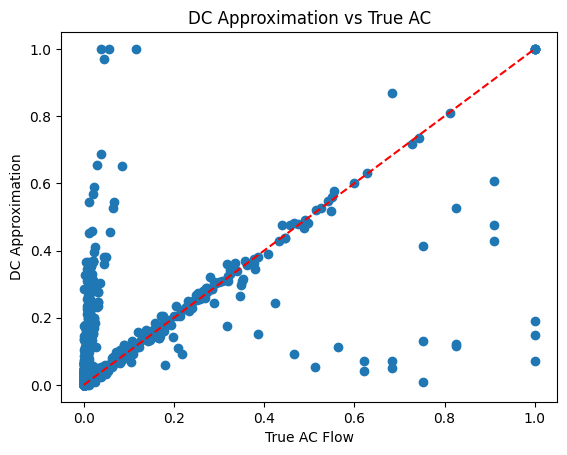


Model: LinearRegression
Training on full dataset...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.04672583054999107
MSE: 0.007371097143335999
RMSE: 0.08585509386947288
R2: 0.6593858820424159


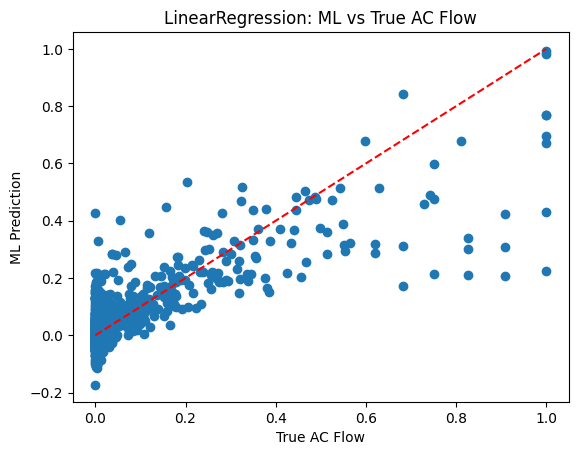


Model: RandomForest
Training on full dataset...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.027890200308728536
MSE: 0.00301336878374661
RMSE: 0.054894159832778296
R2: 0.8607539786279027


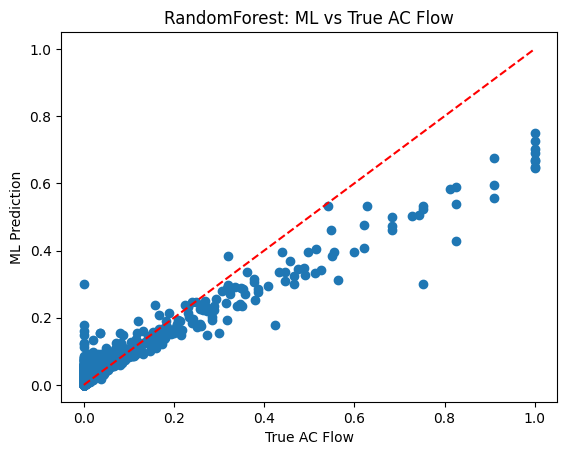


Model: GradientBoosting
Training on full dataset...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.03232508200053286
MSE: 0.0032804050972070637
RMSE: 0.0572748207959402
R2: 0.8484143856740629


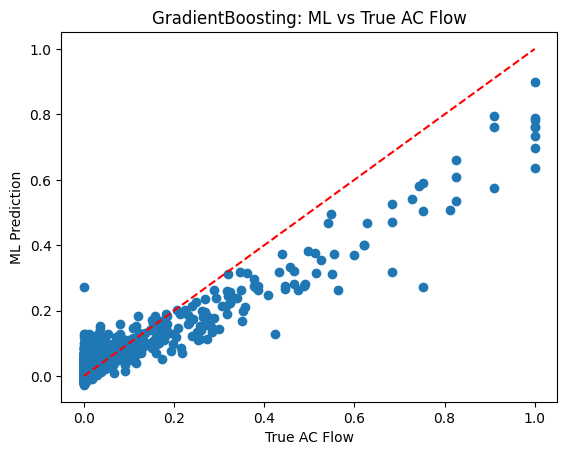


Model: HistGradientBoosting
Training on full dataset...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.0037534753496515708
MSE: 0.0004849291316249019
RMSE: 0.022021106503191477
R2: 0.9775917064680552


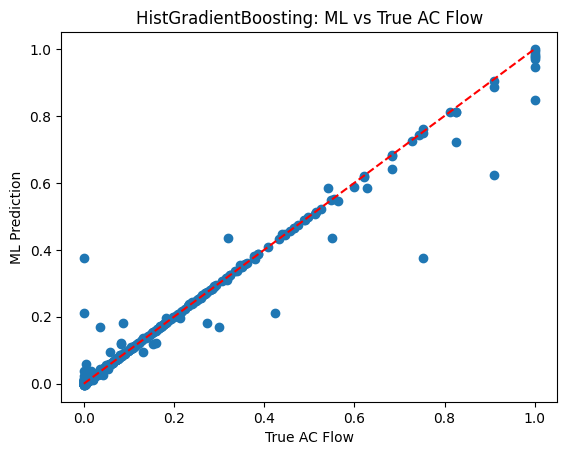


Model: KNNRegressor
Training on full dataset...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.05002819628704599
MSE: 0.012110259699221622
RMSE: 0.11004662511509211
R2: 0.440391932778029


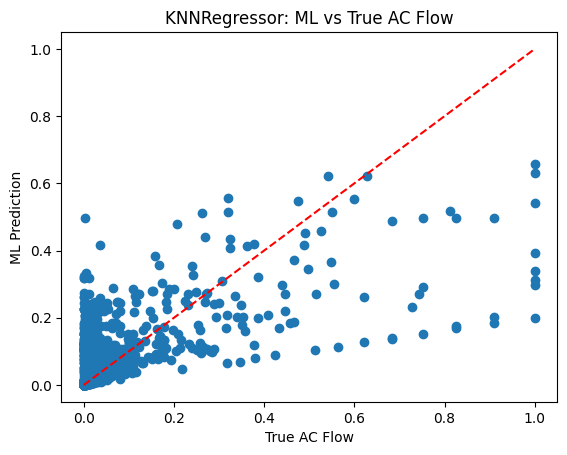


Model: SVR
Training on full dataset...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.08250857204891635
MSE: 0.013247727875213493
RMSE: 0.11509877442967624
R2: 0.3878301889919543


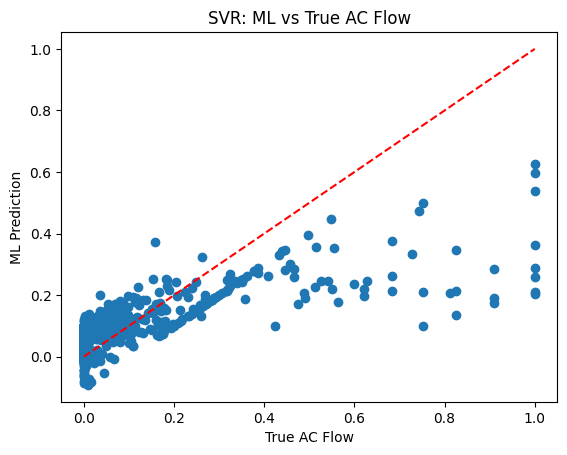

In [530]:
# prepare our features and targets for training models (full dataset, no split)
# remember that first two columns are network type and edge index so we dont include them
X_train = aura_dataset.iloc[:, 2:-2].values
y_train = aura_dataset['target'].values
dc_approx = aura_dataset['dc_approx'].values

# scale our features before training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# print DC approximation vs AC true flow
print('\n### DC Approximation vs True AC ###')
print_report_regression(y_train, dc_approx)
print_regression_scatter(y_train, dc_approx, xlabel='True AC Flow', ylabel='DC Approximation', title='DC Approximation vs True AC')

# train and evaluate each model on all the data to see if we can learn something
for name, model in MODELS.items():
    print(f'\n{"="*60}\nModel: {name}\n{"="*60}')
    print('Training on full dataset...')
    model.fit(X_scaled, y_train)
    preds = model.predict(X_scaled)

    print('\n### Comparison: ML Prediction vs True AC Flow ###')
    print_report_regression(y_train, preds)
    print_regression_scatter(y_train, preds, xlabel='True AC Flow', ylabel='ML Prediction', title=f'{name}: ML vs True AC Flow')

Perform train-test split on all networks, we learn on all the networks and test on unseen edges (inductive test).

First, plot DC vs AC power flow to compare approximations.

Then, plot ML model predictions vs true AC power flow to evaluate model accuracy.

In [531]:
# we save the train and test indcies for splitting data
train_indices, test_indices = [], []

# iterate over each network in dataset and split into train and test using indices (inductive)
for netword_id in aura_dataset['network'].unique():
    network_indices = aura_dataset[aura_dataset['network'] == netword_id].index
    train, test = train_test_split(network_indices, test_size=0.2, random_state=42)
    train_indices.extend(train)
    test_indices.extend(test)

# get our train and test dataframes using our splitted indices
train_df = aura_dataset.loc[train_indices]
test_df  = aura_dataset.loc[test_indices]
print('Train size:', len(train_df))
print('Test size:', len(test_df))

test_df

Train size: 986
Test size: 251


,network,edge_index,t0,t1,t2,t3,t4,t5,t6,t7,...,t992,t993,t994,t995,t996,t997,t998,t999,dc_approx,target
0,14,0,-0.099972,-0.149972,-0.394805,-0.574742,-0.133095,0.851637,1.365548,0.628246,...,0.000069,0.000033,0.000002,0.000017,0.000061,0.000079,0.000044,-0.000008,1.000000,1.000000
17,14,17,-0.799978,-0.016645,0.676022,0.555474,-0.166748,-0.637244,-0.302431,0.533629,...,-0.000006,0.000047,0.000066,0.000039,0.000006,0.000001,0.000019,0.000032,0.363626,0.335389
15,14,15,-0.799987,0.233346,1.000180,0.566287,-0.539410,-1.071139,-0.544437,0.380018,...,-0.000027,0.000003,0.000044,0.000045,0.000003,-0.000030,-0.000011,0.000042,0.205456,0.171883
1,14,1,-0.099974,-0.399974,-0.406474,0.080406,0.488632,0.328482,-0.027251,0.101843,...,0.000005,0.000031,0.000060,0.000059,0.000033,0.000014,0.000019,0.000030,0.481345,0.465156
50,57,30,-0.137675,0.112325,0.257325,0.292536,0.490838,0.727543,0.637703,0.308578,...,-0.000179,-0.000166,-0.000168,-0.000183,-0.000199,-0.000207,-0.000201,-0.000187,0.017504,0.002870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1232,145,448,-1.360978,0.134303,1.362328,1.130629,0.139023,-0.258602,0.156589,0.481555,...,0.000025,-0.000069,-0.000133,-0.000069,0.000030,0.000010,-0.000116,-0.000177,0.062428,0.001914
921,145,137,-1.520600,0.073802,1.035790,-0.168942,-2.216801,-2.326005,0.185692,2.628764,...,0.000375,0.000370,0.000319,0.000263,0.000284,0.000391,0.000480,0.000452,0.011146,0.000606
877,145,93,0.559430,-0.155954,-0.489082,0.175755,1.105607,1.203466,0.409578,-0.345586,...,-0.000206,-0.000128,-0.000078,-0.000120,-0.000202,-0.000229,-0.000188,-0.000161,0.004108,0.000163
841,145,57,0.879017,0.886592,0.789263,0.643106,0.598124,0.605526,0.550037,0.539381,...,-0.000643,-0.000633,-0.000639,-0.000646,-0.000649,-0.000659,-0.000675,-0.000685,0.000801,0.000082



### DC Approximation vs True AC ###
MAE: 0.04550856537782504
MSE: 0.01600713036570447
RMSE: 0.12651928851248126
R2: 0.3763676913492753


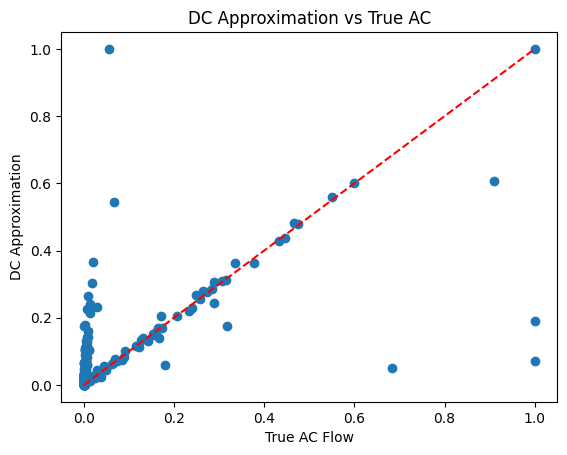


Model: LinearRegression

Training LinearRegression on dataset with inductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.12027431360381083
MSE: 0.042095417549727274
RMSE: 0.2051716782349047
R2: -0.6400230291369471


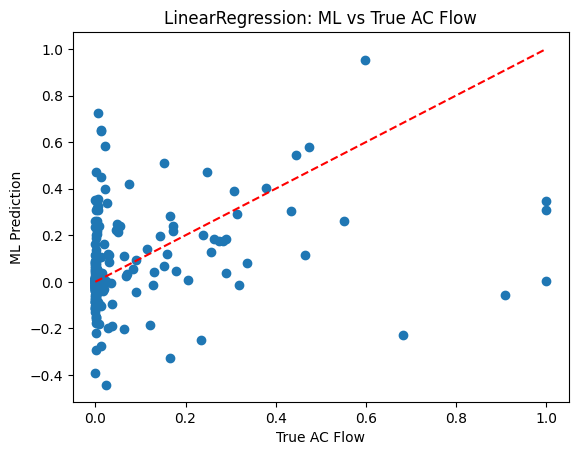


Model: RandomForest

Training RandomForest on dataset with inductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.08283818939631014
MSE: 0.02327697362909763
RMSE: 0.1525679311949193
R2: 0.0931370913416475


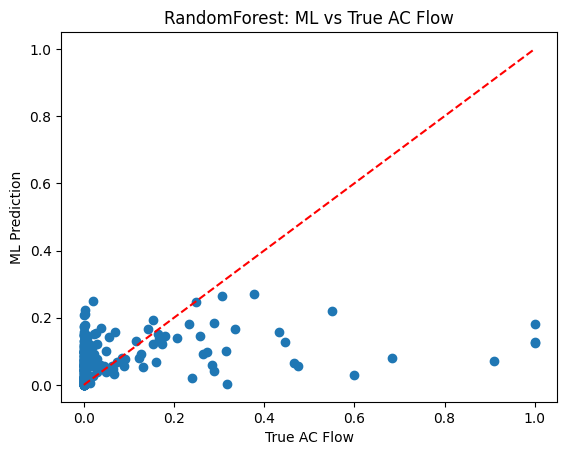


Model: GradientBoosting

Training GradientBoosting on dataset with inductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.07584533252718258
MSE: 0.023371597983877043
RMSE: 0.15287772232695332
R2: 0.08945055893530807


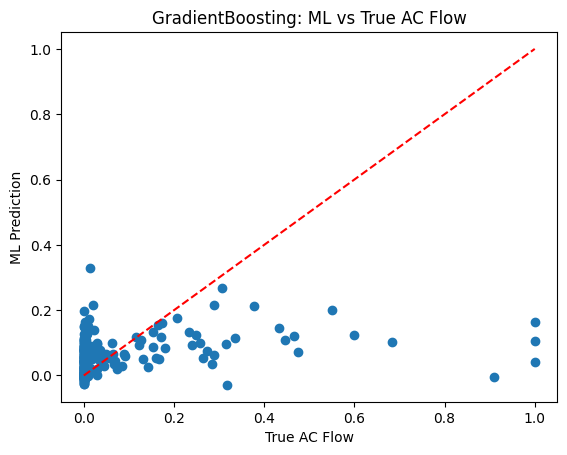


Model: HistGradientBoosting

Training HistGradientBoosting on dataset with inductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.0716032250097602
MSE: 0.021878731632217967
RMSE: 0.14791460925891656
R2: 0.14761211994731904


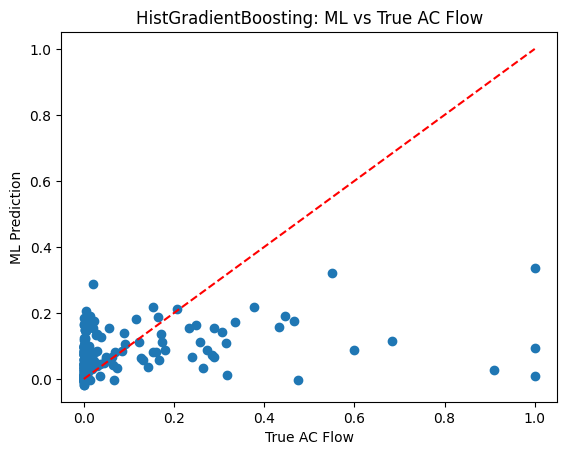


Model: KNNRegressor

Training KNNRegressor on dataset with inductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.0735548269499068
MSE: 0.024579573296839786
RMSE: 0.15677873993893363
R2: 0.04238825507414479


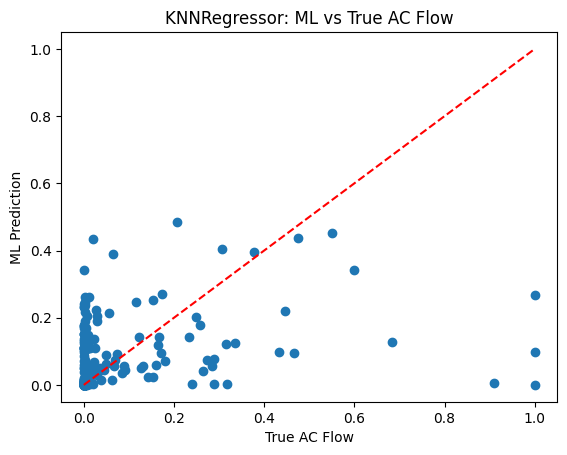


Model: SVR

Training SVR on dataset with inductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.09823797978593148
MSE: 0.023529580002601812
RMSE: 0.15339354615694173
R2: 0.08329563367314385


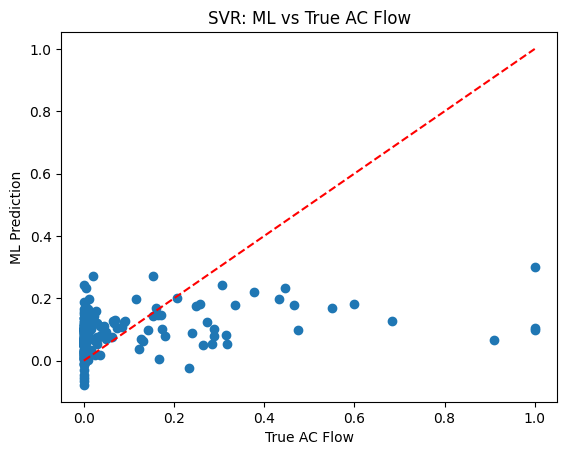

In [532]:
# prepar our data and remove first colmums of metadata before training
X_train, y_train = train_df.iloc[:, 2:-2].values, train_df['target'].values
X_test, y_test  = test_df.iloc[:, 2:-2].values, test_df['target'].values
y_dc_approx = test_df['dc_approx'].values # this is our test dc approximation

# scale our features before training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# print DC approximation vs AC true flow
print('\n### DC Approximation vs True AC ###')
print_report_regression(y_test, y_dc_approx)
print_regression_scatter(y_test, y_dc_approx, xlabel='True AC Flow', ylabel='DC Approximation', title='DC Approximation vs True AC')

# train and evaluate each model on all networks and test on unseen rows from different networks (inductive)
for name, model in MODELS.items():
    print(f'\n{"="*60}\nModel: {name}\n{"="*60}')
    print(f'\nTraining {name} on dataset with inductive split...')
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    print('\n### Comparison: ML Prediction vs True AC Flow ###')
    print_report_regression(y_test, preds)
    print_regression_scatter(y_test, preds, xlabel='True AC Flow', ylabel='ML Prediction', title=f'{name}: ML vs True AC Flow')

Perform train-test split such that we learn on all the networks except one and test on unseen network (transductive test).

First, plot DC vs AC power flow to compare approximations.

Then, plot ML model predictions vs true AC power flow to evaluate model accuracy.

In [533]:
test_network = 57

train_df = aura_dataset[aura_dataset['network'] != test_network]
test_df  = aura_dataset[aura_dataset['network'] == test_network]
print('Train size:', len(train_df))
print('Test size:', len(test_df))

test_df.head()

Train size: 1157
Test size: 80


,network,edge_index,t0,t1,t2,t3,t4,t5,t6,t7,...,t992,t993,t994,t995,t996,t997,t998,t999,dc_approx,target
20,57,0,-0.137374,0.145959,-0.076374,-0.820955,-1.071162,-0.364616,0.443083,0.501775,...,0.000135,0.000136,0.000134,0.000130,0.000124,0.000124,0.000136,0.000148,0.544240,0.067135
21,57,1,0.218845,-0.297822,-0.604155,-0.326056,0.064164,0.012403,-0.308610,-0.318154,...,0.000109,0.000133,0.000133,0.000112,0.000081,0.000063,0.000073,0.000104,0.527562,0.064860
22,57,2,-0.849857,-0.199857,0.212143,0.001042,-0.262925,-0.133959,0.040387,-0.084715,...,0.000149,0.000172,0.000175,0.000159,0.000141,0.000130,0.000123,0.000125,0.359095,0.045755
23,57,3,-0.493639,-0.293639,-0.139306,-0.114893,-0.035126,0.181006,0.307871,0.172890,...,0.000091,0.000127,0.000139,0.000121,0.000114,0.000123,0.000112,0.000079,0.071167,0.008256
24,57,4,-1.206105,-0.089439,0.485450,-0.160057,-0.712207,-0.011395,1.072911,0.977340,...,0.000122,0.000136,0.000165,0.000177,0.000167,0.000148,0.000129,0.000121,0.058722,0.007816



### DC Approximation vs True AC ###
MAE: 0.16003951993424909
MSE: 0.06733596847925229
RMSE: 0.2594917503105875
R2: -0.5280875885208254


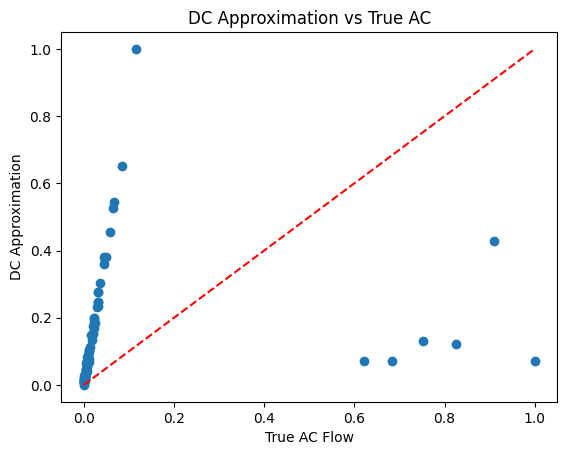


Model: LinearRegression

Training LinearRegression on dataset with transductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 371036751.7897682
MSE: 2.077415764237353e+17
RMSE: 455786766.39820874
R2: -4.714379724866852e+18


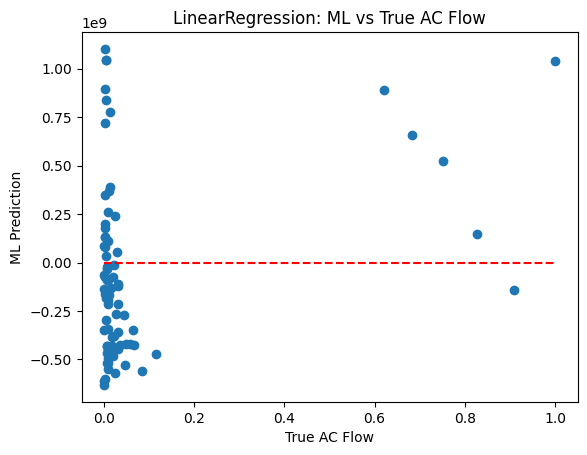


Model: RandomForest

Training RandomForest on dataset with transductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.11300428590478946
MSE: 0.043971165723305394
RMSE: 0.20969302735977036
R2: 0.002141142214675318


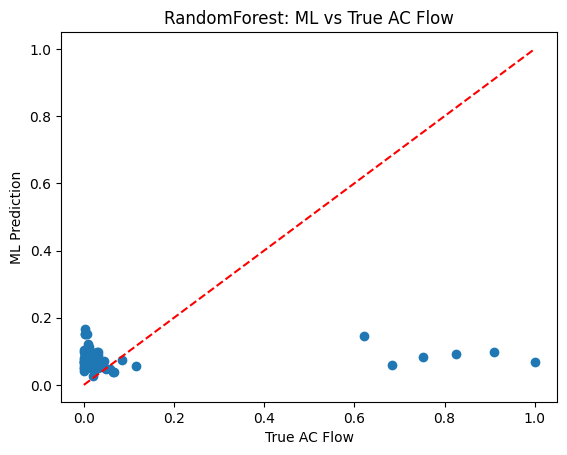


Model: GradientBoosting

Training GradientBoosting on dataset with transductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.12416629788017589
MSE: 0.047253687669875186
RMSE: 0.21737913347392657
R2: -0.07235071048877328


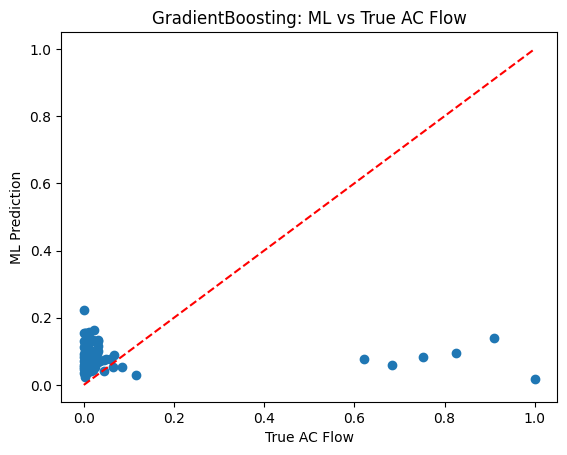


Model: HistGradientBoosting

Training HistGradientBoosting on dataset with transductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.12302134560506894
MSE: 0.049012551962985096
RMSE: 0.22138778639072457
R2: -0.11226546566188489


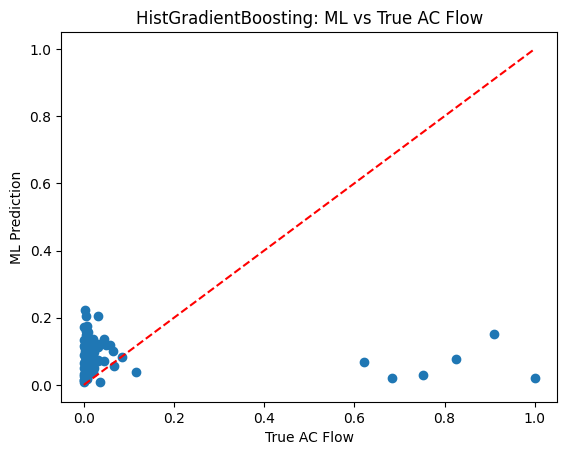


Model: KNNRegressor

Training KNNRegressor on dataset with transductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.2358547213749438
MSE: 0.0766965617508083
RMSE: 0.27694144101381485
R2: -0.7405120434221255


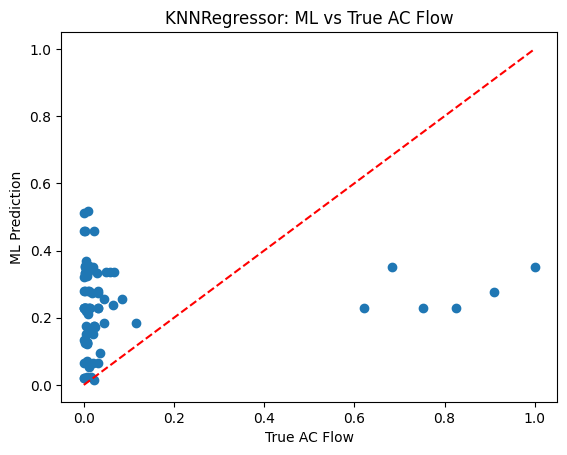


Model: SVR

Training SVR on dataset with transductive split...

### Comparison: ML Prediction vs True AC Flow ###
MAE: 0.16984806917607892
MSE: 0.05173973229337334
RMSE: 0.22746369445116585
R2: -0.17415468339562046


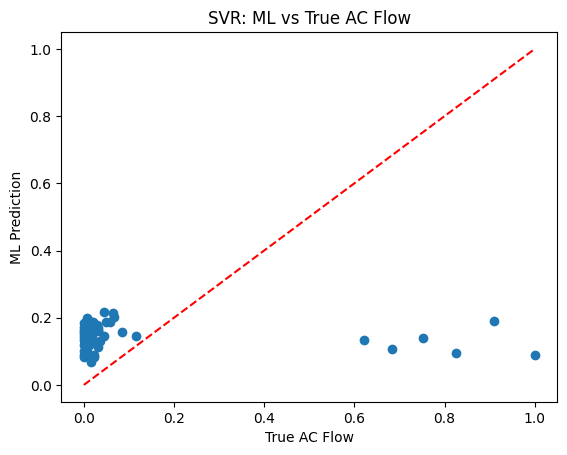

In [534]:
# prepar our data and remove first colmums of metadata before training
X_train, y_train = train_df.iloc[:, 2:-2].values, train_df['target'].values
X_test, y_test  = test_df.iloc[:, 2:-2].values, test_df['target'].values
y_dc_approx = test_df['dc_approx'].values # this is our test dc approximation

# scale our features before training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# print DC approximation vs AC true flow
print('\n### DC Approximation vs True AC ###')
print_report_regression(y_test, y_dc_approx)
print_regression_scatter(y_test, y_dc_approx, xlabel='True AC Flow', ylabel='DC Approximation', title='DC Approximation vs True AC')

# train and evaluate each model on all networks except one and test on unseen network (transductive)
for name, model in MODELS.items():
    print(f'\n{"="*60}\nModel: {name}\n{"="*60}')
    print(f'\nTraining {name} on dataset with transductive split...')
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    print('\n### Comparison: ML Prediction vs True AC Flow ###')
    print_report_regression(y_test, preds)
    print_regression_scatter(y_test, preds, xlabel='True AC Flow', ylabel='ML Prediction', title=f'{name}: ML vs True AC Flow')